# Cross-correlation
Cross-correlation measures the temporal relationship between the firing of two neurons. It is useful to identify synchronization phenomena at the network level.

In [146]:
# Import libraries
import numpy as np
import scipy
import matplotlib.pyplot as plt
from scipy.sparse import issparse

def plot_spike_train(peak_train, sfreq, ax):
    """
    Plot a spike train.

    Parameters:
    peak_train (numpy array): Spike train data.
    sfreq (float): Sampling frequency in Hz.
    ax (matplotlib.axes.Axes): Axes object for plotting.

    Returns:
    None
    """
    time_axis = np.arange(peak_train.size) / sfreq
    ax.plot(time_axis, peak_train, lw=.1, color='k', label='Spike')
    ax.set(xlabel='Time (s)', ylabel='Spike')
    ax.set_yticks([])
    ax.spines[['top', 'right']].set_visible(False)

## Load and plot data

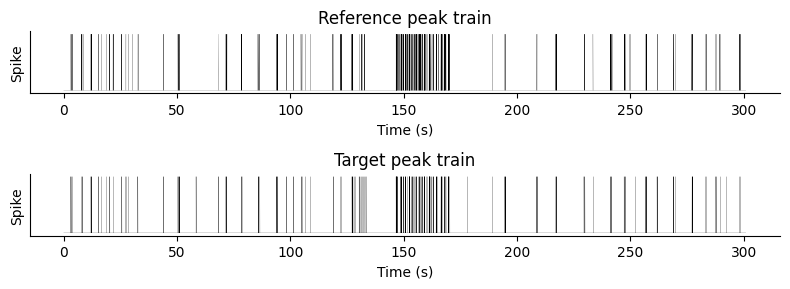

In [147]:
reference = scipy.io.loadmat('ptrain_620_DIV34_01_nbasal1_1_12.mat')['peak_train']
target = scipy.io.loadmat('ptrain_620_DIV34_01_nbasal1_1_14.mat')['peak_train']

# Ensure reference and target are dense arrays
def to_dense_array(data):
    """
    Convert sparse data to dense array if necessary.

    Parameters:
    data (scipy.sparse.csr_matrix or numpy.ndarray): Input data.

    Returns:
    numpy.ndarray: Dense array representation of the input data.
    """
    if issparse(data):
        return data.toarray().flatten()  # Convert to dense and flatten to 1D if necessary
    else:
        return np.asarray(data).flatten()

reference = to_dense_array(reference)
target = to_dense_array(target)

reference[reference > 0] = 1
target[target > 0] = 1

# Sampling frequency
sfreq = 10_000

# Plot the data
fig, axs = plt.subplots(2, 1, figsize=(8, 3))

plot_spike_train(reference, sfreq, axs[0])
axs[0].set_title('Reference peak train')
plot_spike_train(target, sfreq, axs[1])
axs[1].set_title('Target peak train')

fig.tight_layout()

## Cross-correlation implementation
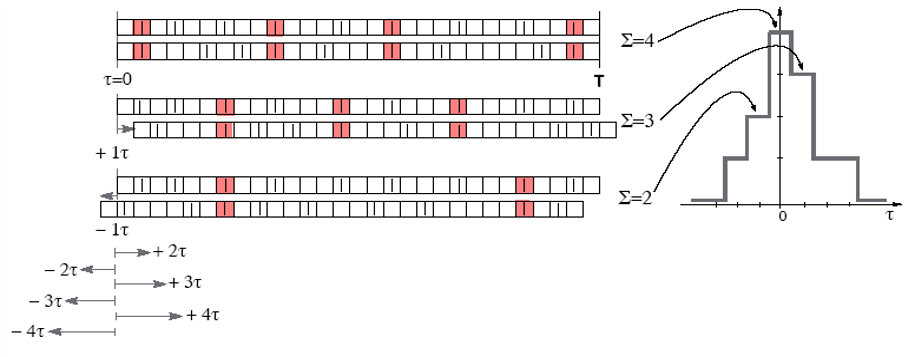

In [148]:
def compute_cross_correlation(reference, target, tau, dtau, sfreq, bin_size):
    """
    Compute cross-correlation between two spike trains.

    Parameters:
    reference (numpy array): Reference spike train.
    target (numpy array): Target spike train.
    tau (float): Time delay for cross-correlation.
    dtau (float): Time step for cross-correlation.
    sfreq (float): Sampling frequency in Hz.

    Returns:
    numpy array: Cross-correlation values.
    """
    # binning
    bin_size_sample = int(bin_size * sfreq)
    reference_bin = np.zeros(int(len(reference) / bin_size_sample), dtype=bool)
    target_bin = np.zeros(int(len(target) / bin_size_sample), dtype=bool)

    i = 0
    while i + bin_size_sample <= len(reference):
        reference_bin[i // bin_size_sample] = np.any(reference[i:i+bin_size_sample])
        target_bin[i // bin_size_sample] = np.any(target[i:i+bin_size_sample])
        i += bin_size_sample

    tau = int((tau * sfreq) / (sfreq * bin_size))
    dtau = int(dtau * sfreq / (sfreq * bin_size))
    x_tau = np.arange(-tau, tau + 1, dtau)
    cross_corr = np.zeros_like(x_tau)

    pos_ref = np.nonzero(reference_bin)[0]

    for i in pos_ref:
        targ_i = target_bin[i + x_tau.astype(int)]
        cross_corr += targ_i

    cross_corr = cross_corr / np.sqrt(np.sum(reference_bin) * np.sum(target_bin))

    return cross_corr

bin_size = 1e-3
dtau = 5 * 1e-3
tau = 150 * 1e-3

tau_axis = np.arange(-tau, tau + dtau, dtau)

cross_corr = compute_cross_correlation(reference, target, tau, dtau, sfreq, bin_size)

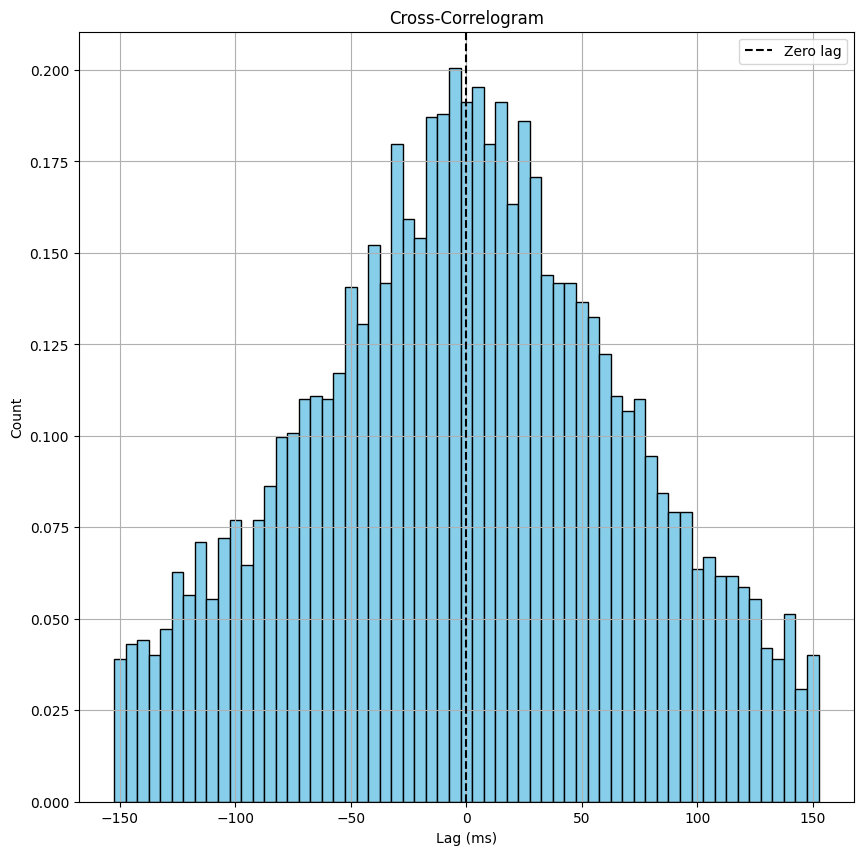

In [149]:
def plot_crosscorrelogram(xaxis, cross_corr, sfreq, ax):
    """
    Plot the cross-correlogram as a bar graph.

    Parameters:
    xaxis (numpy array): Time axis values.
    cross_corr (numpy array): Cross-correlation values.
    sfreq (float): Sampling frequency.
    ax (matplotlib.axes.Axes): Axes object for plotting.

    Returns:
    None
    """
    xaxis_ms = xaxis * 1000
    width = (xaxis_ms[1] - xaxis_ms[0]) if len(xaxis_ms) > 1 else 1 # width of each bar (in milliseconds)

    # Plot
    ax.bar(xaxis_ms, cross_corr, width=width, align='center', color='skyblue', edgecolor="black")
    ax.axvline(0, color='black', linestyle='--', label='Zero lag')
    ax.set_xlabel('Lag (ms)')
    ax.set_ylabel('Count')
    ax.set_title('Cross-Correlogram')
    ax.grid(True)
    ax.legend()
    

# Plot the cross-correlogram
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
plot_crosscorrelogram(tau_axis, cross_corr, sfreq, ax)